## Normalization (MinMaxScaling)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("./data/wine_data.csv", header=None, usecols=[0,1,2])
df.columns=['Class label', 'alcohol', 'malic acid']

In [36]:
df.head()

,Class label,alcohol,malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

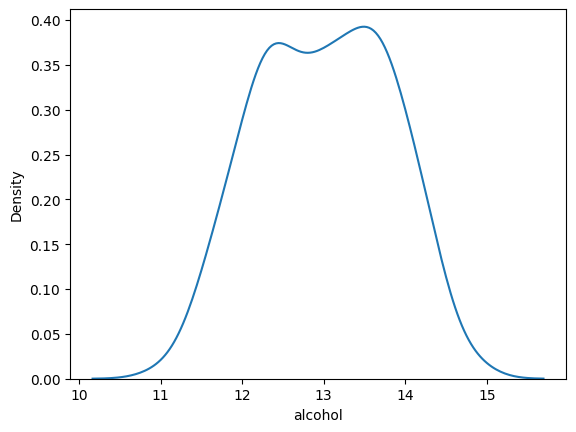

In [37]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic acid', ylabel='Density'>

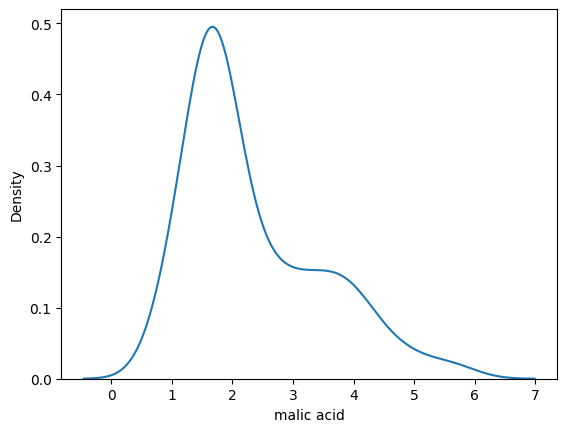

In [38]:
sns.kdeplot(df['malic acid'])

<Axes: xlabel='alcohol', ylabel='malic acid'>

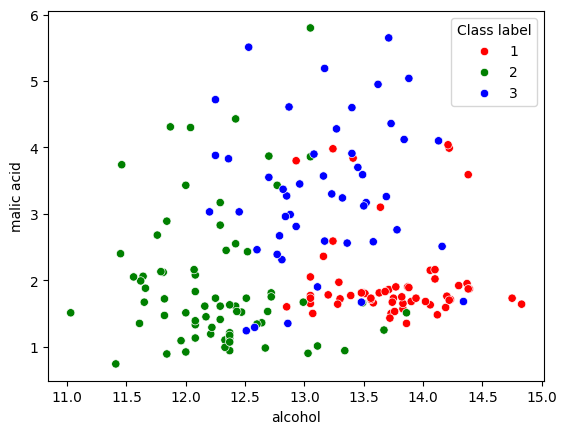

In [39]:
color = {1 :'red', 2: 'green', 3: 'blue'}
sns.scatterplot(x=df['alcohol'], y=df['malic acid'], hue=df['Class label'], palette=color)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  df.drop('Class label', axis=1),
  df['Class label'],
  test_size=0.3,
  random_state=0
)

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [43]:
np.round(X_train.describe(), 1)

,alcohol,malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [44]:
np.round(X_train_scaled.describe(), 1)

,alcohol,malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


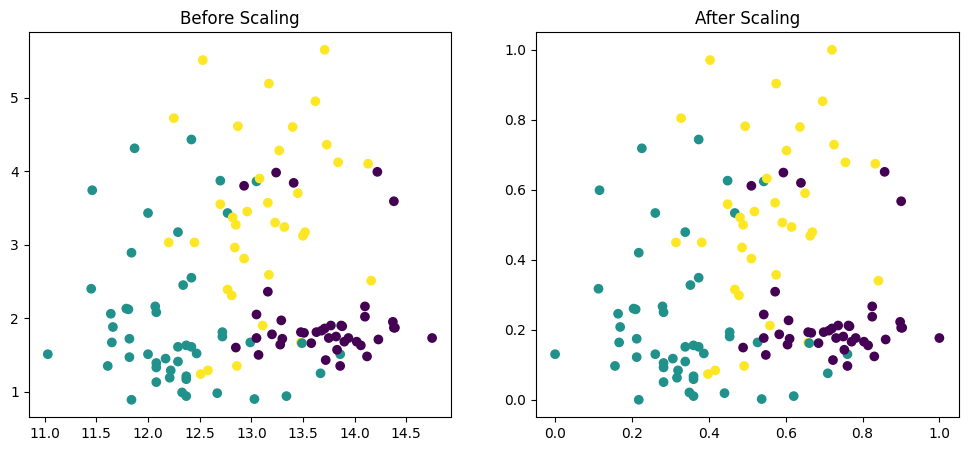

In [45]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
axes[0].scatter(X_train['alcohol'],X_train['malic acid'], c=y_train)
axes[0].set_title("Before Scaling")

# After Scaling
axes[1].scatter(X_train_scaled['alcohol'],X_train_scaled['malic acid'], c=y_train)
axes[1].set_title("After Scaling")

plt.show()

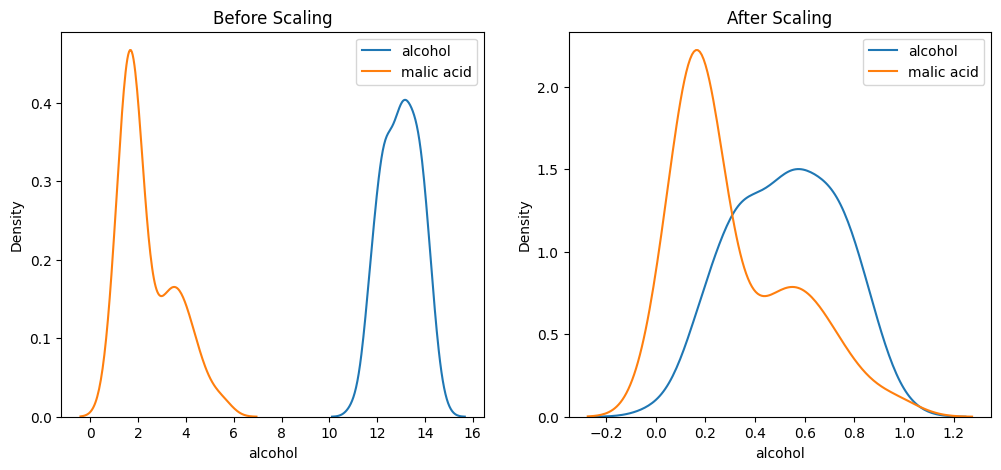

In [46]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
sns.kdeplot(X_train['alcohol'], label='alcohol', ax = axes[0])
sns.kdeplot(X_train['malic acid'], label='malic acid', ax = axes[0])
axes[0].set_title("Before Scaling")
axes[0].legend()

# After Scaling
sns.kdeplot(X_train_scaled['alcohol'], label='alcohol', ax = axes[1])
sns.kdeplot(X_train_scaled['malic acid'], label='malic acid', ax = axes[1])
axes[1].set_title("After Scaling")
axes[1].legend()

plt.show()

## Importance of scaling

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print(f"Actual : {accuracy_score(y_test, y_pred)}")
print(f"Scaled : {accuracy_score(y_test, y_pred_scaled)}")

Actual : 0.7592592592592593
Scaled : 0.7962962962962963


In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn_scaled = KNeighborsClassifier()

knn.fit(X_train, y_train)
knn_scaled.fit(X_train_scaled, y_train)

print("Actual:", accuracy_score(y_test, knn.predict(X_test)))
print("Scaled:", accuracy_score(y_test, knn_scaled.predict(X_test_scaled)))


Actual: 0.8148148148148148
Scaled: 0.8148148148148148


## When to use Normalization

In [49]:
# use in following algorithms


# Distance-based Algorithms

# K-Means
# KNN
# Hierarchical Clustering
# DBSCAN



# Gradient-based Algorithms

# Linear Regression (Gradient Descent based)
# Logistic Regression
# Neural Networks / Deep Learning
# Perceptron


# Support Vector Machines (SVM)

In [50]:
# When to now use (optional)

# Decision Trees
# Random Forest
# XGBoost / LightGBM / CatBoost
# Naive Bayes